# Imputação de Genes do Mathys pela Modern Hopfield Network (11k Expandida)

Neste notebook, contornaremos as limitações da rede anterior de 5k gerando memórias de forma unificada (`11.279 genes`). Treinamos uma nova representação Hopfield dinamicamente nos moldes expandidos originais do `Fujita`, passamos o dataset `Mathys` carregado de buracos biológicos (`0.5`), resolvemos as equações via rede e preenchemos unicamente os gaps, salvando tudo no final!

In [8]:
import os, sys, gc
import numpy as np, pandas as pd, polars as pl
import anndata as ad
import torch
import warnings
warnings.filterwarnings("ignore")

SRC_DIR = os.path.join(os.getcwd(), 'src')
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

from config import (
    PATH_F, PATH_FEATURES_F, PATH_FEATURES_M, PATH_LABELS_F, PATH_SWEEP_F,
    OUT_ALINHAMENTO, OUT_BINARIZACAO, OUT_HOPFIELD, OUT_TOP_GENES
)
from alinhamento.alinhador import Alinhador
from alinhamento.leitor_features import LeitorFeatures
from treinamento.extrator_padroes import ExtratorPadroesSubcluster
from treinamento.hopfield import ModernHopfieldNetwork

print("✅ Bibliotecas carregadas.")

✅ Bibliotecas carregadas.


## 1. Carregando Ordenação do Genoma Alvo (11k)

In [9]:
leitor = LeitorFeatures(PATH_FEATURES_F, PATH_FEATURES_M)
leitor.ler()

path_genes_target = os.path.join(OUT_TOP_GENES, 'genes_expandidos_frequentes.csv')
genes_ordenados = pd.read_csv(path_genes_target)['gene'].tolist()
gene_alvo_idx = {eid: i for i, eid in enumerate(genes_ordenados)}
print(f"Alvos mapeados: {len(genes_ordenados)} genes")

[LeitorFeatures] Fujita : 36591 genes mapeados
[LeitorFeatures] Mathys : 32643 genes mapeados
Alvos mapeados: 11279 genes


## 2. Instanciando o Modelo Original Extrativo Equivalente (Fujita 11.279)

In [10]:
path_bin_f = os.path.join(OUT_BINARIZACAO, 'matrizFiltradaeNormalizadaF', 'matrizBinarizadaM.h5ad')
print("[Fujita] Carregando H5AD base binarizado...")
adataf = ad.read_h5ad(path_bin_f)

alinhador = Alinhador("fake", "fake", OUT_ALINHAMENTO, 
                      leitor.map_f, leitor.map_m, gene_alvo_idx, genes_ordenados)

print("[Fujita] Alinhando ao eixo expandido com fill_value=0.0...")
adata_fujita_exp = alinhador._alinhar_direto(adataf, leitor.map_f, fill_value=0.0)
W0_fujita = adata_fujita_exp.X
import scipy.sparse as sp
if sp.issparse(W0_fujita): W0_fujita = W0_fujita.toarray()
print(f"[Fujita] Dimensões W0 puras (11k) geradas na memória -> {W0_fujita.shape}")
del adataf, adata_fujita_exp
gc.collect()

[Fujita] Carregando H5AD base binarizado...
[Fujita] Alinhando ao eixo expandido com fill_value=0.0...
[Fujita] Dimensões W0 puras (11k) geradas na memória -> (40913, 11279)


142

## 3. Extraindo Subclusters e Memórias (Padrões da Hopfield)

In [11]:
print("Carregando SWeeP embeddings (para facilitar/encurtar a clusterização sem perdas):", PATH_SWEEP_F)
Wswp_f = pd.read_csv(PATH_SWEEP_F).to_numpy(dtype=np.float32)

print("Carregando Rótulos Labels:", PATH_LABELS_F)
labels_f = np.loadtxt(PATH_LABELS_F, dtype=int).ravel()

# O SWeeP roda agrupando e o W0 (11k) será de onde extraímos os dados
extrator = ExtratorPadroesSubcluster(W0=W0_fujita, labels=labels_f, classes=[1, 2, 3, 4, 5, 6, 7], k=1)
extrator.extrair(Wswp_f)

perf35_11k = extrator.padroes
print(f"Protótipos (perf35) fechados em formato definitivo: {perf35_11k.shape}")

Carregando SWeeP embeddings (para facilitar/encurtar a clusterização sem perdas): c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\treinamento\matriz_reduzida_sweepF.csv
Carregando Rótulos Labels: c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\imputs\cell_types_binarioF.txt
[ExtratorPadroesSubcluster] Classe 1: n=4366 Aplicando estratégia de clusterização...
[EstrategiaKMeansDinamico] Melhor k encontrado: 10 (Calinski-Harabasz: 57.96)
[ExtratorPadroesSubcluster] Classe 2: n=188 Aplicando estratégia de clusterização...
[EstrategiaKMeansDinamico] Melhor k encontrado: 10 (Calinski-Harabasz: 4.96)
[ExtratorPadroesSubcluster] Classe 3: n=9073 Aplicando estratégia de clusterização...
[EstrategiaKMeansDinamico] Melhor k encontrado: 10 (Calinski-Harabasz: 135.47)
[ExtratorPadroesSubcluster] Classe 4: n=4567 Aplicando estratégia de clusterização...
[EstrategiaKMeansDinamico] Melhor k encontrado: 10 (Calinski-Harabasz: 93.38)
[ExtratorPadroesSubcluster] Classe 5: n=

## 4. Single-Shot Training no Novo Dataset 11K

In [12]:
rede35 = ModernHopfieldNetwork(beta=30.0, n_iters=1, binary=True, threshold=0.0)
rede35.store(perf35_11k)

os.makedirs(OUT_HOPFIELD, exist_ok=True)
path_rede = os.path.join(OUT_HOPFIELD, 'rede35_expandida_11k.pt')
rede35.salvar(path_rede)
print(f"Rede treinada com 11k gravada e serializada -> {path_rede}")

[ModernHopfieldNetwork] 70 padrões armazenados (11279 genes, device=cpu)
[ModernHopfieldNetwork] Rede salva em: c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\hopfield\rede35_expandida_11k.pt (70 padrões)
Rede treinada com 11k gravada e serializada -> c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\hopfield\rede35_expandida_11k.pt


## 5. Inferência (Imputação e Restauro de 0.5)

In [13]:
path_mathys_11k = os.path.join(OUT_ALINHAMENTO, 'Mathys_Binarizado_Alinhado_Expandido.txt')
print(f"Carregando Matriz Mathys Expandida: {path_mathys_11k}")
Mathys_Original_05 = pd.read_csv(path_mathys_11k).to_numpy(dtype=np.float32)

gaps_antes = np.sum(Mathys_Original_05 == 0.5)
print(f"\n[STATUS INICIAL] Total de genes ausentes biológicos mapeados: {gaps_antes}")

print("Forçando rede de Hopfield a convergir e recuperar sinais ausentes nos dados Mathys (Batch: 4096)...")
Mathys_Output = rede35.retrieve(Mathys_Original_05, batch_size=4096)

print("Mesclando resultados por Mask (Preservando 100% da identidade da amostra original != 0.5)...")
Mathys_Final = np.where(Mathys_Original_05 == 0.5, Mathys_Output, Mathys_Original_05)

gaps_depois = np.sum(Mathys_Final == 0.5)
print(f"[STATUS FINAL] Total de genes ausentes não formatados: {gaps_depois}")

Carregando Matriz Mathys Expandida: c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\alinhamento\Mathys_Binarizado_Alinhado_Expandido.txt

[STATUS INICIAL] Total de genes ausentes biológicos mapeados: 291010299
Forçando rede de Hopfield a convergir e recuperar sinais ausentes nos dados Mathys (Batch: 4096)...
[ModernHopfieldNetwork] Recuperação concluída: torch.Size([45663, 11279])
Mesclando resultados por Mask (Preservando 100% da identidade da amostra original != 0.5)...
[STATUS FINAL] Total de genes ausentes não formatados: 0


## 6. Avaliação das Métricas de Reconstrução
Calculamos a acurácia, f1-score, taxa de reconstrução e plotamos a matriz de confusão sobre os resultados de `Mathys_Output` usando a classe genérica do sistema.

Carregando Rótulos Mathys (labels reais)...
Instanciando o AvaliadorHopfield...

=================== RESULTADOS ===================
[AvaliadorHopfield] Mapeando padrões recuperados para classes...
[AvaliadorHopfield] Acurácia: 66.51% (n=45,663)
[AvaliadorHopfield] F1 macro=0.6189, F1 ponderado=0.6994
[AvaliadorHopfield] Taxa de reconstrução exata : 99.21%
[AvaliadorHopfield] Semelhança média ao protótipo: 0.9997
              precision    recall  f1-score   support

           1       1.00      0.50      0.67      2597
           2       0.02      0.71      0.05       159
           3       1.00      0.57      0.72     24548
           4       0.42      0.57      0.48      6420
           5       0.93      0.86      0.89       485
           6       0.66      1.00      0.80      9218
           7       0.66      0.80      0.72      2236

    accuracy                           0.67     45663
   macro avg       0.67      0.71      0.62     45663
weighted avg       0.83      0.67      0.7

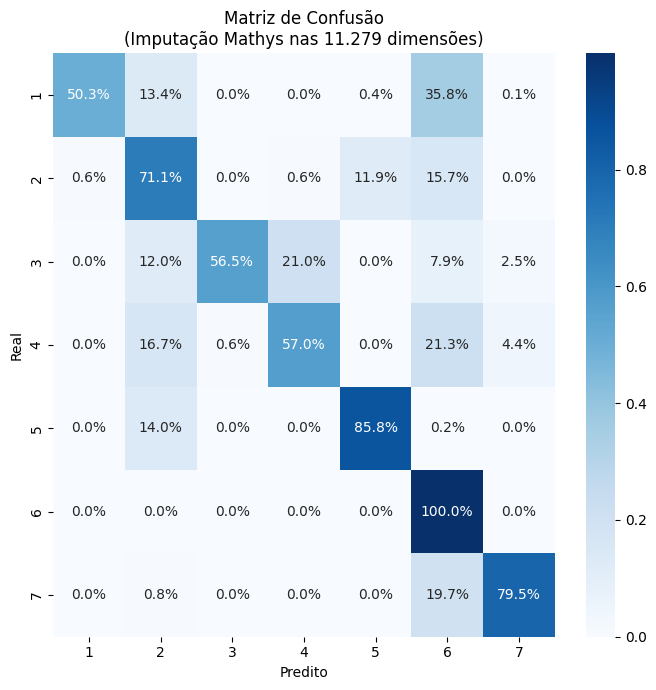

AvaliadorHopfield(
  padroes            = (70, 11279)
  classes            = [1, 2, 3, 4, 5, 6, 7]
  nc                 = 10
  acuracia           = 66.51%
  f1_macro           = 0.6189
  f1_weighted        = 0.6994
  taxa_reconstrucao  = 99.21%
  semelhanca_media   = 0.9997
)

In [14]:
from config import PATH_LABELS_M
from treinamento import AvaliadorHopfield

print("Carregando Rótulos Mathys (labels reais)...")
labels_m = np.loadtxt(PATH_LABELS_M, dtype=int).ravel()

# Remapeamento padrão clo
clo_m = labels_m.copy()
clo_m[~np.isin(clo_m, [1, 3, 4, 5, 6, 7, 0])] = 2

print("Instanciando o AvaliadorHopfield...")
avaliador = AvaliadorHopfield(
    padroes = perf35_11k,                     # Memórias usadas na Hopfield
    classes = [1, 2, 3, 4, 5, 6, 7],          # As 7 classes principais do sistema
    nc = 10,                                  # Número de clusters de configuração padrão
    meta = extrator.meta                      # Relação subcluster => subclasse real extraída e preservada acima
)

print("\n=================== RESULTADOS ===================")
# 1. Mathys_Output é o Y_pred (saída da rede) e clo_m é o Y_true reais do experimento
avaliador.avaliar(Mathys_Output, clo_m)
print("==================================================\n")

# 2. Mostrar Matriz de Confusão e fechar visual
avaliador.plotar(titulo='Matriz de Confusão\n(Imputação Mathys nas 11.279 dimensões)', normalizado=True)


## 7. Salvar Mathys Corrigido

In [15]:
path_out = os.path.join(OUT_TOP_GENES, 'Mathys_Imputado_Final_rede35.npy')
np.save(path_out, Mathys_Final)
print(f"TUDO PRONTO! Array exportado como NPY (muito mais rápido para Torch loading futuramente): {path_out}")

TUDO PRONTO! Array exportado como NPY (muito mais rápido para Torch loading futuramente): c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\top_genes\Mathys_Imputado_Final_rede35.npy
